# Gastronorm With Many Objects

# 1 Import

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform

pd.set_option("display.width", 220, "display.max_columns", 80)

REPO = Path.cwd().parent
EXPERIMENTS_DIR = REPO / "experiments"

# 2 Load Dataframe

In [2]:
EXPERIMENT = 'gastronorm_many_objects'
SPEAKER = 1
OBJECT = 'candle'

In [3]:
EXPERIMENT = os.environ.get("EXPERIMENT", "gastronorm_many_objects")
SPEAKER = int(os.environ.get("SPEAKER", "1"))
OBJECT = os.environ.get("OBJECT", "candle")
# REFERENCE_POSITION = os.environ.get("REFERENCE_POSITION", "")
# DISTANCE_METRIC = os.environ.get("DISTANCE_METRIC", "cosine")

matches = sorted(p for p in EXPERIMENTS_DIR.iterdir() if p.is_dir() and EXPERIMENT in p.name)
assert matches, f"no experiment dir under {EXPERIMENTS_DIR} matching {EXPERIMENT!r}"
assert len(matches) == 1, f"ambiguous EXPERIMENT {EXPERIMENT!r}, matches: {matches}"
DATASET_DIR = matches[0]
SAMPLES_DIR = DATASET_DIR / "samples"
assert SAMPLES_DIR.is_dir(), SAMPLES_DIR

print(f"EXPERIMENT         = {EXPERIMENT!r} -> {DATASET_DIR}")
print(f"SPEAKER             = {SPEAKER!r}")
print(f"OBJECT              = {OBJECT!r}")

EXPERIMENT         = 'gastronorm_many_objects' -> /home/ethantu/workspace/good-vibrations/experiments/2026_09_23_gastronorm_many_objects
SPEAKER             = 1
OBJECT              = 'candle'


In [4]:
def read_metadata(sample_dir: Path) -> dict:
    meta = {}
    for line in (sample_dir / "metadata.jsonl").read_text().splitlines():
        line = line.strip()
        if line:
            meta.update(json.loads(line))
    return meta


def parse_com(v):
    """avg_com -> [com0, com1], handling list/tuple/ndarray/numpy-repr-string/None/[-1,-1]."""
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None
    if isinstance(v, str):
        s = v.strip("[]").replace(",", " ").strip()
        parts = [float(x) for x in s.split()] if s else []
    elif isinstance(v, (list, tuple, np.ndarray)):
        parts = np.asarray(v, dtype=float).ravel().tolist()
    else:
        return None
    if len(parts) < 2:
        return None
    if parts[0] < 0 or parts[1] < 0:
        return None
    return parts[:2]


In [5]:
rows = []
for sample_dir in sorted(p for p in SAMPLES_DIR.glob("*") if p.is_dir()):
    if not (sample_dir / "metadata.jsonl").exists():
        continue
    meta = read_metadata(sample_dir)
    com = parse_com(meta.get("avg_com"))
    fft_path = sample_dir / "vibration" / "04_ffts.npz"
    rows.append(dict(
        sample_id=meta.get("sample_id"),
        position_id=meta.get("position_id"),
        speaker=meta.get("speaker"),
        is_empty_box=bool(meta.get("is_empty_box")),
        n_objects=meta.get("n_objects"),
        object_type=next(iter(meta.get("objects") or {}), None),
        timestamp=meta.get("timestamp"),
        width=meta.get("width"),
        height=meta.get("height"),
        com0=com[0] if com else np.nan,
        com1=com[1] if com else np.nan,
        sample_dir=str(sample_dir),
        fft_path=str(fft_path) if fft_path.exists() else None,
    ))

df = pd.DataFrame(rows)
print(f"loaded {len(df)} samples from {SAMPLES_DIR}")
df.head()

loaded 556 samples from /home/ethantu/workspace/good-vibrations/experiments/2026_09_23_gastronorm_many_objects/samples


,sample_id,position_id,speaker,is_empty_box,n_objects,object_type,timestamp,width,height,com0,com1,sample_dir,fft_path
0,000001,1,1,True,0,NaN,2026-09-23T16:37:23.010214+00:00,1040,300,NaN,NaN,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
1,000002,1,3,True,0,NaN,2026-09-23T16:37:24.290212+00:00,1040,300,NaN,NaN,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
2,000003,1,5,True,0,NaN,2026-09-23T16:37:25.590673+00:00,1040,300,NaN,NaN,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
3,000004,1,7,True,0,NaN,2026-09-23T16:37:26.891598+00:00,1040,300,NaN,NaN,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
4,000005,2,1,True,0,NaN,2026-09-23T16:37:37.408277+00:00,1040,300,NaN,NaN,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...


In [6]:
df_speaker = df[df["speaker"] == SPEAKER].copy()
print(f"speaker {SPEAKER}: {len(df_speaker)} / {len(df)} samples")
df_speaker.head()

speaker 1: 139 / 556 samples


,sample_id,position_id,speaker,is_empty_box,n_objects,object_type,timestamp,width,height,com0,com1,sample_dir,fft_path
0,000001,1,1,True,0,NaN,2026-09-23T16:37:23.010214+00:00,1040,300,NaN,NaN,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
4,000005,2,1,True,0,NaN,2026-09-23T16:37:37.408277+00:00,1040,300,NaN,NaN,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
8,000009,3,1,True,0,NaN,2026-09-23T16:37:48.476338+00:00,1040,300,NaN,NaN,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
12,000013,4,1,False,1,soap dispenser,2026-09-23T16:40:54.361092+00:00,1040,300,319.425034,306.113611,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...
16,000017,5,1,False,1,soap dispenser,2026-09-23T16:41:06.762512+00:00,1040,300,898.420965,313.355709,/home/ethantu/workspace/good-vibrations/experi...,/home/ethantu/workspace/good-vibrations/experi...


# 3 Plot Positions

In [7]:
df_object = df_speaker[(df_speaker["object_type"] == OBJECT) & df_speaker["fft_path"].notna()].copy()
assert len(df_object), f"no samples with object_type == {OBJECT!r} for speaker {SPEAKER}"
df_object = df_object.sort_values("position_id").reset_index(drop=True)
df_object["layout_idx"] = np.arange(len(df_object))

print(f"OBJECT={OBJECT!r}, speaker={SPEAKER}: {len(df_object)} positions")
df_object[["layout_idx", "sample_id", "position_id", "com0", "com1"]]

OBJECT='candle', speaker=1: 7 positions


,layout_idx,sample_id,position_id,com0,com1
0,0,000125,32,353.778866,341.705146
1,1,000129,33,905.696739,348.854760
2,2,000133,34,889.052277,1124.331031
3,3,000137,35,345.248652,1138.386563
4,4,000141,36,587.675548,771.031945
5,5,000145,37,594.307982,791.391367
6,6,000149,38,590.050885,807.235402


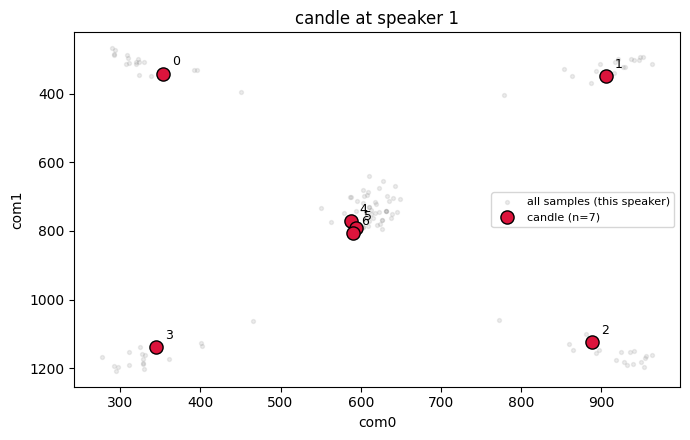

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(df_speaker["com0"], df_speaker["com1"], s=8, alpha=0.15, color="gray", label="all samples (this speaker)")
ax.scatter(df_object["com0"], df_object["com1"], s=90, color="crimson", edgecolors="black", label=f"{OBJECT} (n={len(df_object)})")
for _, r in df_object.iterrows():
    ax.annotate(str(r.layout_idx), (r.com0, r.com1), textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.invert_yaxis()
ax.set_xlabel("com0")
ax.set_ylabel("com1")
ax.set_title(f"{OBJECT} at speaker {SPEAKER}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 4 Normalize Signal

In [9]:
def to_logmag(fft_path):
    # load fft
    with np.load(fft_path) as z: fft, freqs = z["fft"], z["freqs"] # (B, L, F, C), (F,)

    # get magnitude
    mag = np.abs(fft)[0] # (B, L, F, C) -> (L, F, C)

    # avg across all 100 lasers and x,y channels
    mag = mag.mean(axis=(0, 2)) # (L, F, C) -> (F,)

    # take log
    logmag = np.log(np.maximum(mag, np.percentile(mag, 1))) # (F,) -> (F,)

    return mag, logmag, freqs

In [10]:
object_mags, object_logmags = [], []
for fft_path in df_object["fft_path"]:
    mag, logmag, freqs = to_logmag(fft_path)
    object_mags.append(mag)
    object_logmags.append(logmag)

FREQS = freqs
OBJECT_MAG = np.stack(object_mags)          # (n_positions, F)
OBJECT_LOGMAG = np.stack(object_logmags)    # (n_positions, F)

OBJECT_LOGMAG.shape

(7, 1235)

In [11]:
empty_df = df[df["is_empty_box"] & df["fft_path"].notna()]
speaker_baseline_logmag = {}
for spk, g in empty_df.groupby("speaker"):
    logmags = [to_logmag(fft_path)[1] for fft_path in g["fft_path"]]
    speaker_baseline_logmag[spk] = np.mean(logmags, axis=0)

BASELINE = speaker_baseline_logmag[SPEAKER]
print(f"BASELINE {BASELINE.shape}")

BASELINE (1235,)


In [12]:
RESID = OBJECT_LOGMAG - BASELINE  # (n_positions, F), object signature with speaker response removed

print(f"empty-box baseline computed for speakers: {sorted(speaker_baseline_logmag)}")
print(f"OBJECT_MAG {OBJECT_MAG.shape}, OBJECT_LOGMAG {OBJECT_LOGMAG.shape}, RESID {RESID.shape}")

empty-box baseline computed for speakers: [1, 3, 5, 7]
OBJECT_MAG (7, 1235), OBJECT_LOGMAG (7, 1235), RESID (7, 1235)


In [13]:
REFERENCE_POSITION = 'top-left'

In [14]:
def label_positions(df):
    """Map 'top-left'/'top-right'/'bottom-left'/'bottom-right'/'center-N' -> row index of df."""
    s = df["com0"] + df["com1"]
    d = df["com0"] - df["com1"]
    corner_idx = {
        "top-left": s.idxmin(),
        "bottom-right": s.idxmax(),
        "top-right": d.idxmax(),
        "bottom-left": d.idxmin(),
    }
    # keep only 4 distinct corners (a small df could collide on the same row)
    corner_idx = {name: idx for name, idx in corner_idx.items() if list(corner_idx.values()).count(idx) == 1}

    remaining = [i for i in df.index if i not in corner_idx.values()]
    center_idx = {f"center-{n}": idx for n, idx in enumerate(remaining, start=1)}

    return {**corner_idx, **center_idx}


POSITION_NAME_TO_IDX = label_positions(df_object)


def resolve_reference(df, ref):
    """REFERENCE_POSITION -> a row index of df. Accepts a named position, a sample_id, or an int position_id."""
    if not ref:
        return df.index[0]
    if ref in POSITION_NAME_TO_IDX:
        return POSITION_NAME_TO_IDX[ref]
    if ref in set(df["sample_id"]):
        return df.index[df["sample_id"] == ref][0]
    try:
        ref_pos = int(ref)
    except ValueError:
        raise ValueError(f"REFERENCE_POSITION {ref!r} is not a named position, sample_id, or int position_id")
    matches = df.index[df["position_id"] == ref_pos]
    assert len(matches), f"REFERENCE_POSITION {ref!r} not found among {OBJECT}'s positions for speaker {SPEAKER}"
    return matches[0]


ref_idx = resolve_reference(df_object, REFERENCE_POSITION)
ref_row = df_object.loc[ref_idx]
ref_i = df_object.index.get_loc(ref_idx)
print(f"reference position: layout_idx={ref_row.layout_idx}, sample_id={ref_row.sample_id}, "
      f"position_id={ref_row.position_id}, com=({ref_row.com0:.1f}, {ref_row.com1:.1f})")


reference position: layout_idx=0, sample_id=000125, position_id=32, com=(353.8, 341.7)


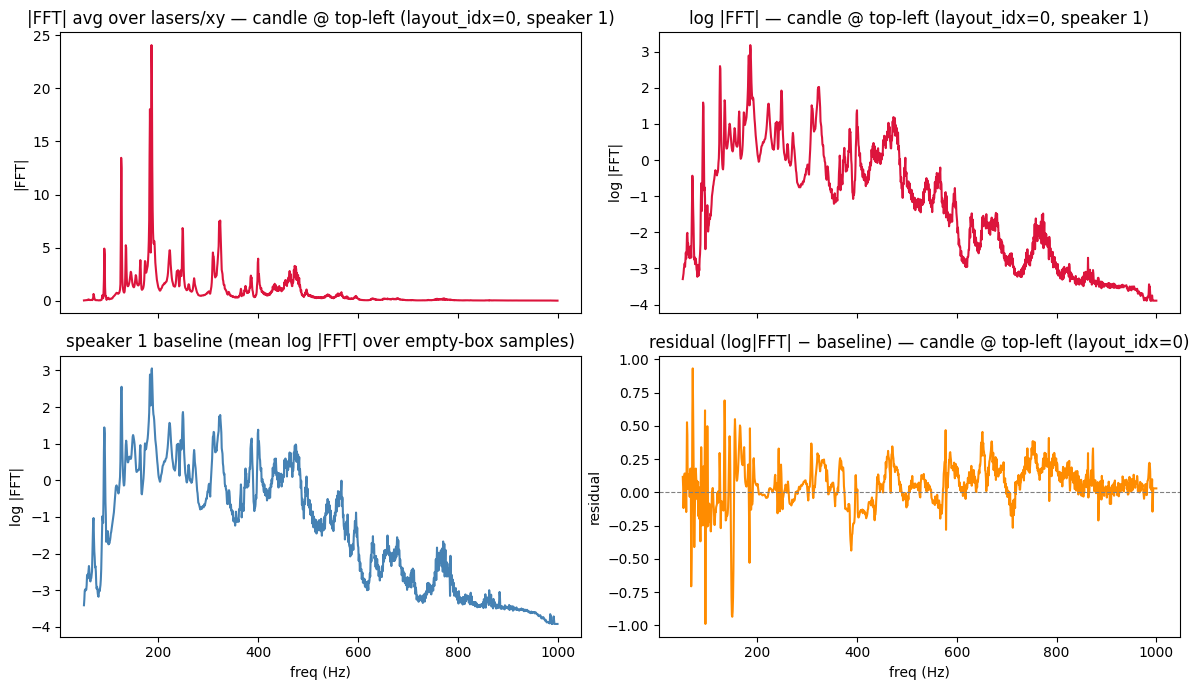

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

ax = axes[0, 0]
ax.plot(FREQS, OBJECT_MAG[ref_i], color="crimson", lw=1.5)
ax.set_title(f"|FFT| avg over lasers/xy — {OBJECT} @ {REFERENCE_POSITION} (layout_idx={ref_row.layout_idx}, speaker {SPEAKER})")
ax.set_ylabel("|FFT|")

ax = axes[0, 1]
ax.plot(FREQS, OBJECT_LOGMAG[ref_i], color="crimson", lw=1.5)
ax.set_title(f"log |FFT| — {OBJECT} @ {REFERENCE_POSITION} (layout_idx={ref_row.layout_idx}, speaker {SPEAKER})")
ax.set_ylabel("log |FFT|")

ax = axes[1, 0]
ax.plot(FREQS, speaker_baseline_logmag[SPEAKER], color="steelblue", lw=1.5)
ax.set_title(f"speaker {SPEAKER} baseline (mean log |FFT| over empty-box samples)")
ax.set_ylabel("log |FFT|")
ax.set_xlabel("freq (Hz)")

ax = axes[1, 1]
ax.plot(FREQS, RESID[ref_i], color="darkorange", lw=1.5)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_title(f"residual (log|FFT| − baseline) — {OBJECT} @ {REFERENCE_POSITION} (layout_idx={ref_row.layout_idx})")
ax.set_ylabel("residual")
ax.set_xlabel("freq (Hz)")

plt.tight_layout()
plt.show()

# 5 Distance

In [31]:
DISTANCE_METRIC = "ncc"

In [32]:
def cosine_distance_matrix(X):
    """Pairwise cosine distance: 1 - dot product of unit-normalized rows, vectorized."""
    unit = X / np.linalg.norm(X, axis=1, keepdims=True)
    return 1.0 - unit @ unit.T


def ncc_distance_matrix(X):
    """Pairwise normalized cross-correlation (zero-lag) distance: 1 - Pearson correlation, vectorized."""
    centered = X - X.mean(axis=1, keepdims=True)
    unit = centered / np.linalg.norm(centered, axis=1, keepdims=True)
    return 1.0 - unit @ unit.T


DISTANCE_METRICS = {
    "cosine": cosine_distance_matrix,
    "ncc": ncc_distance_matrix,
}

In [33]:
def dist_matrix(X, metric=None):
    """Pairwise distance matrix via DISTANCE_METRICS[metric or DISTANCE_METRIC]."""
    return DISTANCE_METRICS[metric or DISTANCE_METRIC](X)


def dist_to_ref(X, ref, metric=None):
    """Distance from a single reference row to every row of X, via the same vectorized metric function."""
    return dist_matrix(np.vstack([ref[None, :], X]), metric=metric)[0, 1:]


DIST_MATRIX = dist_matrix(RESID)  # (n_positions, n_positions)
print(f"{DISTANCE_METRIC} distance matrix: {DIST_MATRIX.shape}")
pd.DataFrame(
    DIST_MATRIX,
    index=df_object["layout_idx"],
    columns=df_object["layout_idx"],
).round(3)

ncc distance matrix: (7, 7)


layout_idx,0,1,2,3,4,5,6
layout_idx,,,,,,,
0,-0.000,0.932,0.751,0.887,0.931,0.904,0.963
1,0.932,0.000,0.595,0.577,0.511,0.598,0.624
2,0.751,0.595,0.000,0.660,0.567,0.615,0.750
3,0.887,0.577,0.660,0.000,0.480,0.536,0.585
4,0.931,0.511,0.567,0.480,-0.000,0.115,0.194
5,0.904,0.598,0.615,0.536,0.115,-0.000,0.200
6,0.963,0.624,0.750,0.585,0.194,0.200,0.000


## Distances Scatter Plot

In [34]:
def text_color_for_value(v, vmin, vmax, cmap):
    """Pick white/black text color for legibility against cmap(v)."""
    norm = plt.Normalize(vmin, vmax)
    r, g, b, _ = plt.get_cmap(cmap)(norm(v))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if luminance < 0.5 else "black"

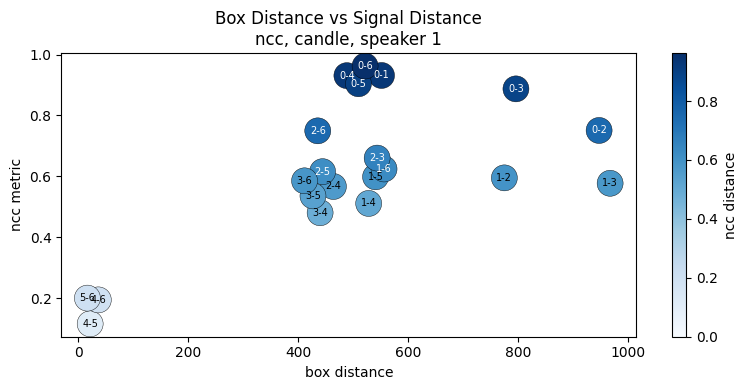

In [35]:
com_xy = df_object[["com0", "com1"]].to_numpy()
box_dist = squareform(pdist(com_xy, metric="euclidean"))

iu = np.triu_indices(len(df_object), k=1)
layout_idx = df_object["layout_idx"].to_numpy()
pair_labels = [f"{layout_idx[i]}-{layout_idx[j]}" for i, j in zip(*iu)]
vmin, vmax = 0, DIST_MATRIX[iu].max()

fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(box_dist[iu], DIST_MATRIX[iu], c=DIST_MATRIX[iu], cmap="Blues", vmin=vmin, vmax=vmax, s=350, edgecolors="black", linewidths=0.3)
for x, y, label in zip(box_dist[iu], DIST_MATRIX[iu], pair_labels):
    ax.annotate(label, (x, y), ha="center", va="center", fontsize=7, color=text_color_for_value(y, vmin, vmax, "Blues"))
ax.set_xlabel("box distance")
ax.set_ylabel(f"{DISTANCE_METRIC} metric")
ax.set_title(f"Box Distance vs Signal Distance\n{DISTANCE_METRIC}, {OBJECT}, speaker {SPEAKER}")
fig.colorbar(sc, ax=ax, label=f"{DISTANCE_METRIC} distance")
plt.tight_layout()
plt.show()

## Layout-idx heatmap

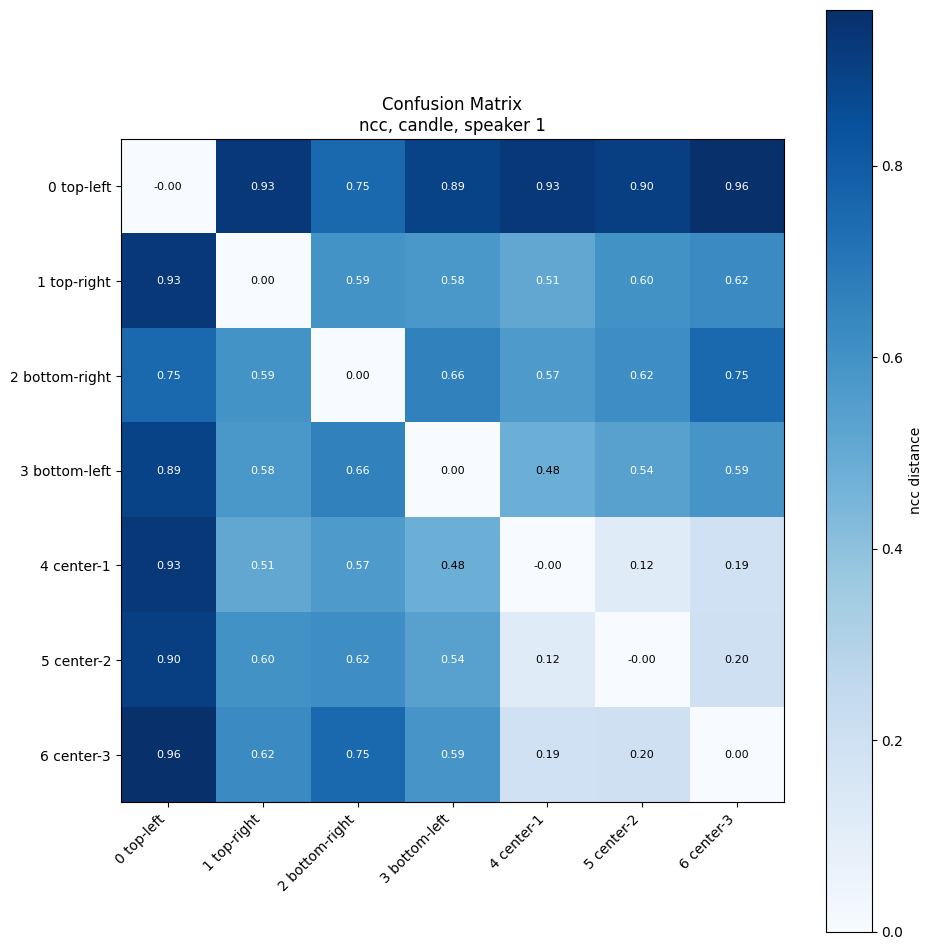

In [36]:
idx_to_position_name = {idx: name for name, idx in POSITION_NAME_TO_IDX.items()}
labels = [f"{r.layout_idx} {idx_to_position_name[i]}" for i, r in df_object.iterrows()]

fig, ax = plt.subplots(figsize=(1.1 * len(df_object) + 2, 1.1 * len(df_object) + 2))
im = ax.imshow(DIST_MATRIX, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        v = DIST_MATRIX[i, j]
        color = "black" if v < DIST_MATRIX.max() / 2 else "white"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color=color, fontsize=8)
ax.set_title(f"Confusion Matrix\n{DISTANCE_METRIC}, {OBJECT}, speaker {SPEAKER}")
fig.colorbar(im, ax=ax, label=f"{DISTANCE_METRIC} distance")
plt.tight_layout()
plt.show()

## Cosine distance from a reference position, plotted in box space

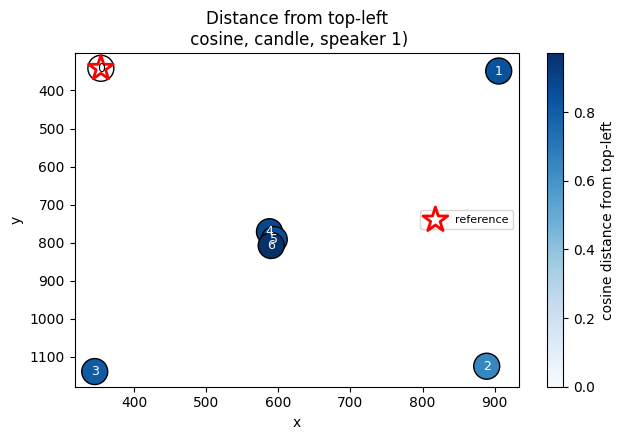

In [30]:
idx_to_position_name = {idx: name for name, idx in POSITION_NAME_TO_IDX.items()}
dist_from_ref = dist_to_ref(RESID, RESID[ref_i], metric=DISTANCE_METRIC)
vmin, vmax = 0, dist_from_ref.max()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sc = ax.scatter(df_object["com0"], df_object["com1"], c=dist_from_ref, cmap="Blues", vmin=vmin, vmax=vmax, s=350, edgecolors="black")
ax.scatter(ref_row.com0, ref_row.com1, marker="*", s=350, facecolors="none", edgecolors="red", linewidths=2, zorder=3, label="reference")
for i, r, v in zip(df_object.index, df_object.itertuples(), dist_from_ref):
    color = text_color_for_value(v, vmin, vmax, "Blues")
    ax.annotate(str(r.layout_idx), (r.com0, r.com1), ha="center", va="center", fontsize=9, color=color)
ax.invert_yaxis()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Distance from {REFERENCE_POSITION}\n {DISTANCE_METRIC}, {OBJECT}, speaker {SPEAKER})")
ax.legend(fontsize=8)
fig.colorbar(sc, ax=ax, label=f"{DISTANCE_METRIC} distance from {REFERENCE_POSITION}")
plt.tight_layout()
plt.show()